In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split
import matplotlib.pyplot as plt

# Transform: normalize + flatten
transform = transforms.Compose([
    transforms.ToTensor(),  # [0,1]
    transforms.Lambda(lambda x: x.view(-1))  # flatten to 784
])

# Load dataset
dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

# Split 80-20
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = random_split(dataset, [train_size, val_size])

print("Train size:", len(train_data))
print("Validation size:", len(val_data))

100.0%
100.0%
100.0%
100.0%

Train size: 48000
Validation size: 12000


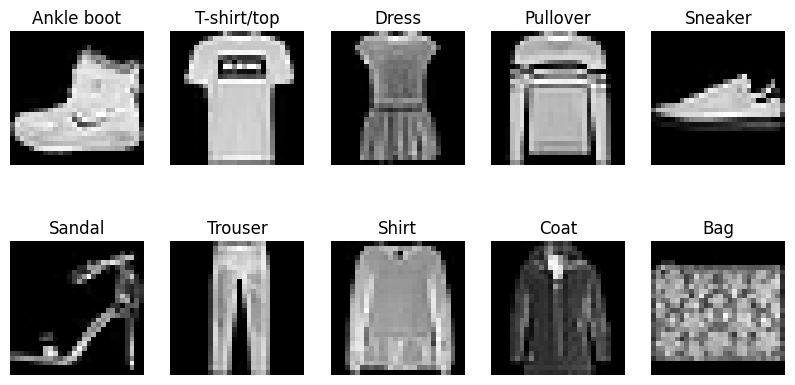

In [4]:
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

shown = set()

for img, label in dataset:
    if label not in shown:
        ax = axes[len(shown)//5, len(shown)%5]
        ax.imshow(img.view(28, 28), cmap="gray")
        ax.set_title(classes[label])
        ax.axis("off")
        shown.add(label)
    if len(shown) == 10:
        break

plt.show()